In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hour = pd.read_csv("hour.csv")
day = pd.read_csv("day.csv")


In [14]:
hour = hour.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
day = day.drop(columns=["instant", "dteday", "yr", "casual", "registered"])
print("Hour dataset after dropping columns:")
print(hour.head().to_string(index=False))

print("\nDay dataset after dropping columns:")
print(day.head().to_string(index=False))


Hour dataset after dropping columns:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1

Day dataset after dropping columns:
 season  mnth  holiday  weekday  workingday  weathersit     temp    atemp      hum  windspeed  cnt
      1     1        0        6           0           2 0.344167 0.363625 0.805833   0.160446  985
      1     1        0        0           0           2 0.363478 0.353739 0.696087   0.248539  801
      1     1        0        1           1           1 0.196364 

In [15]:
hour.isnull().sum()
day.isnull().sum()


season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

In [16]:
hour.dropna(inplace=True)
day.dropna(inplace=True)

In [17]:
hour_duplicates = hour.duplicated().sum()
day_duplicates = day.duplicated().sum()
print("Number of duplicate hours:", hour_duplicates)
print("Number of duplicate days:", day_duplicates)




Number of duplicate hours: 2
Number of duplicate days: 0


In [18]:
hour = hour.drop_duplicates() 
print("Hour dataset after dropping duplicates:")
print(hour.head().to_string(index=False))
day = day.drop_duplicates()

Hour dataset after dropping duplicates:
 season  mnth  hr  holiday  weekday  workingday  weathersit  temp  atemp  hum  windspeed  cnt
      1     1   0        0        6           0           1  0.24 0.2879 0.81        0.0   16
      1     1   1        0        6           0           1  0.22 0.2727 0.80        0.0   40
      1     1   2        0        6           0           1  0.22 0.2727 0.80        0.0   32
      1     1   3        0        6           0           1  0.24 0.2879 0.75        0.0   13
      1     1   4        0        6           0           1  0.24 0.2879 0.75        0.0    1


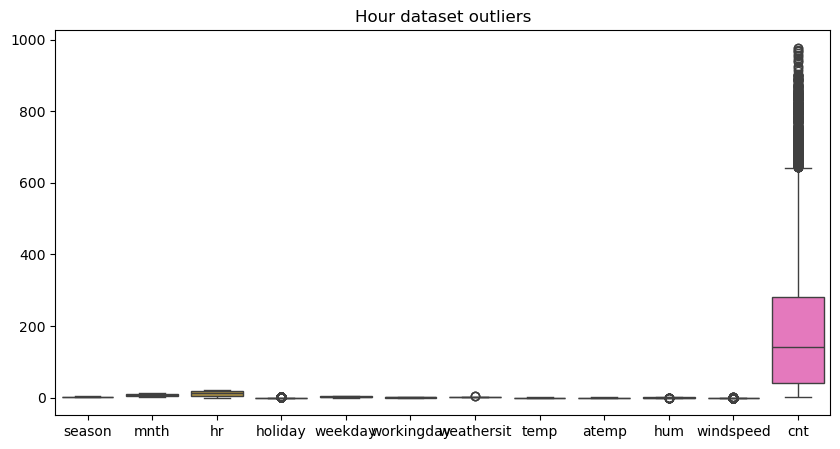

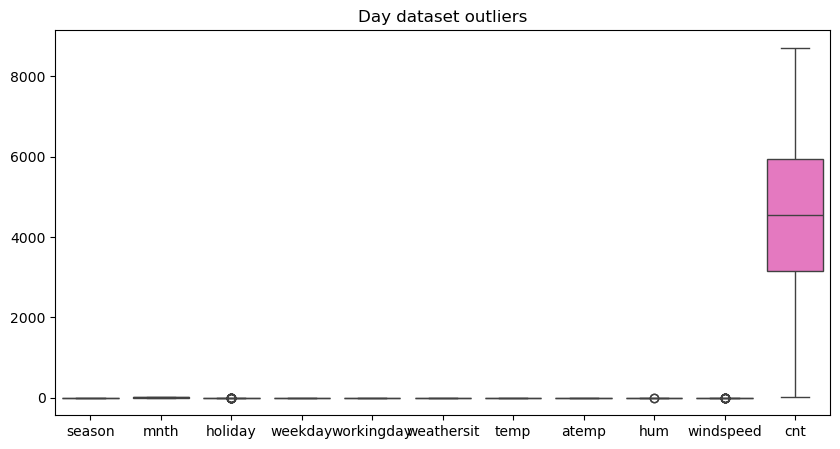

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=hour)
plt.title("Hour dataset outliers")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=day)
plt.title("Day dataset outliers")
plt.show()


In [20]:
Q1 = hour.quantile(0.25)
Q3 = hour.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

hour_cleaned = hour[~((hour < lower_limit) | (hour > upper_limit)).any(axis=1)]

hour_cleaned.shape


(16027, 12)

In [21]:
Q1 = day.quantile(0.25)
Q3 = day.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

day_cleaned = day[~((day < lower_limit) | (day > upper_limit)).any(axis=1)]

day_cleaned.shape


(696, 11)